In [1]:
import sklearn

In [2]:
from sklearn import datasets,linear_model 

In [3]:
from sklearn.metrics import mean_squared_error, r2_score #import 套件計算 r2 mse

In [4]:
from sklearn.datasets import load_diabetes #從scikitlearn資料集中取出糖尿病資料

In [5]:
diabetes = load_diabetes() #設置變數

In [6]:
type(diabetes) #資料型態為bunch,sklearn特有的資料型態. target為series (one_d array)

sklearn.utils.Bunch

In [7]:
print(diabetes) #印出資料 

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990842, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06832974, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286377, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04687948,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452837, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00421986,  0.00306441]]), 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
  

In [8]:
print(diabetes.DESCR) #資料描述 442筆觀測值(病人) 前十個col為數值資料 特徵值 第11為target代表糖尿病經過一年後的進展

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

  :Number of Instances: 442

  :Number of Attributes: First 10 columns are numeric predictive values

  :Target: Column 11 is a quantitative measure of disease progression one year after baseline

  :Attribute Information:
      - age     age in years
      - sex
      - bmi     body mass index
      - bp      average blood pressure
      - s1      tc, total serum cholesterol
      - s2      ldl, low-density lipoproteins
      - s3      hdl, high-density lipoproteins
      - s4      tch, total cholesterol / HDL
      - s5      ltg, possibly log of serum triglycerides level
      - s6      glu, blood sugar level

Note: Each of these 1

In [9]:
print(diabetes.feature_names)  ##印出欄位名，x1＝患者年齡 x2＝性別 x3＝bmi x4＝血壓 x5＝總血清膽固醇 x6=低密度脂蛋白  x7＝高密度脂蛋白 x8＝總膽固醇/高密度脂蛋白 x9=血清甘油三酯水平 x10=血糖值

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [10]:
print(diabetes.target) #印出y array

[151.  75. 141. 206. 135.  97. 138.  63. 110. 310. 101.  69. 179. 185.
 118. 171. 166. 144.  97. 168.  68.  49.  68. 245. 184. 202. 137.  85.
 131. 283. 129.  59. 341.  87.  65. 102. 265. 276. 252.  90. 100.  55.
  61.  92. 259.  53. 190. 142.  75. 142. 155. 225.  59. 104. 182. 128.
  52.  37. 170. 170.  61. 144.  52. 128.  71. 163. 150.  97. 160. 178.
  48. 270. 202. 111.  85.  42. 170. 200. 252. 113. 143.  51.  52. 210.
  65. 141.  55. 134.  42. 111.  98. 164.  48.  96.  90. 162. 150. 279.
  92.  83. 128. 102. 302. 198.  95.  53. 134. 144. 232.  81. 104.  59.
 246. 297. 258. 229. 275. 281. 179. 200. 200. 173. 180.  84. 121. 161.
  99. 109. 115. 268. 274. 158. 107.  83. 103. 272.  85. 280. 336. 281.
 118. 317. 235.  60. 174. 259. 178. 128.  96. 126. 288.  88. 292.  71.
 197. 186.  25.  84.  96. 195.  53. 217. 172. 131. 214.  59.  70. 220.
 268. 152.  47.  74. 295. 101. 151. 127. 237. 225.  81. 151. 107.  64.
 138. 185. 265. 101. 137. 143. 141.  79. 292. 178.  91. 116.  86. 122.
  72. 

In [11]:
print(diabetes.target.shape)
 #印出y.shape,有442個觀察值

(442,)


In [12]:
print(type(diabetes.data))
print(type(diabetes.target)) #印出x y的資料型態

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [13]:
X, y = datasets.load_diabetes(return_X_y=True) #設定X y. X= 10 features of 442 patients   y=target

In [14]:
print(X.shape)
print(y.shape) #確認shape

(442, 10)
(442,)


In [15]:
import numpy as np
from sklearn import metrics
from sklearn.linear_model import LinearRegression

In [16]:
from sklearn.model_selection import train_test_split 

In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0) #分割訓練集 測試集,訓練集70% 測試30%，random state確保結果可複製

In [18]:
print(X_train.shape) #確認切分後的資料是否正確
print(X_test.shape)

(309, 10)
(133, 10)


In [28]:
print(y_train.shape) #確認切分後的資料是否正確
print(y_test.shape)

(309,)
(133,)


In [19]:
lin=LinearRegression()

In [20]:
lin.fit(X_train,y_train) #開始train data

LinearRegression()

In [21]:
y_pred=lin.predict(X_test) #測試集丟入training model,得出預測y值
print(y_pred)

[239.6785766  250.53141737 164.84805461 120.27678545 181.73395543
 262.21230671 112.23276599 191.94646405 151.50037962 236.97547898
 172.17106886 181.76776675 112.11718447  93.10535397 242.61551546
  91.18854011 153.66210217  64.67732159  99.36843868 212.25939578
 197.03895856 162.46443162 164.14281795 157.73824133 207.25537379
 170.20342369 111.97456707  82.77243482 186.91705702 164.72179002
 175.37310208  82.34780886 144.28954965 149.22361436 144.09115907
 194.25825855 166.52462404 188.10488874 126.97750787 205.91826796
  85.53348753 167.78356048 147.74549209 183.84581135 177.14794619
  71.92344074 139.84126287 139.03021418 125.12177811 231.42294135
 163.79584007  78.92939231 151.43859067 159.59729648 237.28907635
 176.12271938 191.69740342 118.93503631 131.10139145 174.80265252
 216.57324581 169.87858747 156.38305845 113.57344508 261.96459935
 155.5688548   84.32840048 228.12498242 208.51229775  46.19025943
  76.55977912 133.97092372 108.91547153 143.46905811 134.31324118
 190.25053

In [22]:
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))  #計算MSE,計算預測準確度

print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred)) #計算R2,看模型解釋力

Mean squared error: 3097.15
Coefficient of determination: 0.39


In [23]:
print(np.sqrt(metrics.mean_squared_error(y_test,y_pred))) #計算MRSE,計算預測準確度

55.65200929335614


In [25]:
#回歸模型： y(一年後糖尿病進展的測量)＝ b0(截距項) +b1X1(患者年齡) +b2X2(性別)+b3X3(bmi)+b4X4(血壓)+b5X5(總血清膽固醇)+b6X6(低密度脂蛋白)+b7X7(高密度脂蛋白)+b8X8(總膽固醇/高密度脂蛋白)+b9X9(血清甘油三酯水平)+b10X10(血糖值)+e(誤差)


ValueError: x and y must be the same size

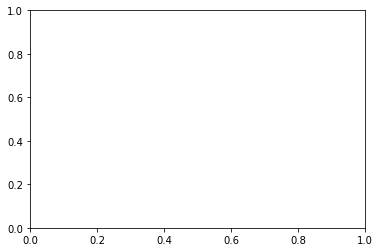

In [27]:
import matplotlib.pyplot as plt
# Plot outputs
plt.scatter(X_test, y_test, color="black")
plt.plot(X_test,y_pred, color="blue", linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()